In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import requests
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
#pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
DATA_DIR = Path("Data")
END_DATE = "2026-01-31"
DELAY_THRESHOLD = 5 

In [4]:
# notice that the 2022-2024 data are xlsx files while 2025+ is a csv file 
xlsx_sources = [
    (DATA_DIR/"ttc-subway-delay-data-2022.xlsx", "2022"),
    (DATA_DIR/"ttc-subway-delay-data-2023.xlsx", "2023"),
    (DATA_DIR/"ttc-subway-delay-data-2024.xlsx", "Subway"),
]
dfs = [pd.read_excel(p, sheet_name=s) for p, s in xlsx_sources]

# 2025+ csv has an extra _id column so we must drop it
df_2025 = pd.read_csv(DATA_DIR / "TTC Subway Delay Data since 2025.csv")
df_2025 = df_2025.drop(columns=["_id"], errors="ignore")
dfs.append(df_2025)

df = pd.concat(dfs, ignore_index=True)
print(f"Combined shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range : {pd.to_datetime(df['Date']).min().date()} to {pd.to_datetime(df['Date']).max().date()}")
df.head(10)

Combined shape : 97,502 rows x 10 columns
Date range : 2022-01-01 to 2026-01-31


,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
0,2022-01-01 00:00:00,15:59,Saturday,LAWRENCE EAST STATION,SRDP,0,0,N,SRT,3023
1,2022-01-01 00:00:00,02:23,Saturday,SPADINA BD STATION,MUIS,0,0,NaN,BD,0
2,2022-01-01 00:00:00,22:00,Saturday,KENNEDY SRT STATION TO,MRO,0,0,NaN,SRT,0
3,2022-01-01 00:00:00,02:28,Saturday,VAUGHAN MC STATION,MUIS,0,0,NaN,YU,0
4,2022-01-01 00:00:00,02:34,Saturday,EGLINTON STATION,MUATC,0,0,S,YU,5981
5,2022-01-01 00:00:00,05:40,Saturday,QUEEN STATION,MUNCA,0,0,NaN,YU,0
6,2022-01-01 00:00:00,06:56,Saturday,DAVISVILLE STATION,MUNCA,0,0,NaN,YU,0
7,2022-01-01 00:00:00,06:58,Saturday,ST PATRICK STATION,MUNCA,0,0,NaN,YU,0
8,2022-01-01 00:00:00,07:01,Saturday,PAPE STATION,MUNCA,0,0,NaN,BD,0
9,2022-01-01 00:00:00,07:43,Saturday,WILSON STATION,TUATC,10,0,S,YU,5896


In [5]:
info_df = pd.DataFrame({
    "dtype"     : df.dtypes,
    "non_null"  : df.notna().sum(),
    "null_count": df.isna().sum(),
    "null_%"    : (df.isna().mean() * 100).round(1),
})
print(info_df.to_string())
print("Min Delay Statistics:")
print(df["Min Delay"].describe().round(2).to_string())

            dtype  non_null  null_count  null_%
Date       object     97502           0     0.0
Time          str     97502           0     0.0
Day           str     97502           0     0.0
Station       str     97502           0     0.0
Code          str     97502           0     0.0
Min Delay   int64     97502           0     0.0
Min Gap     int64     97502           0     0.0
Bound         str     63680       33822    34.7
Line          str     97296         206     0.2
Vehicle     int64     97502           0     0.0
Min Delay Statistics:
count    97502.00
mean         3.06
std         11.90
min          0.00
25%          0.00
50%          0.00
75%          4.00
max        900.00


In [7]:
# since Line 3 was discontinued, it is safe to drop it
length_before_drop = len(df)
df = df[df["Line"] != "SRT"].copy()
print(f"Rows dropped: {length_before_drop - len(df)}")  

# normalize line column since there are many unecessary varaints of the same line
LINE_NORM = {
    # YU (line 1) variants
    "YUS": "YU", "LINE 1": "YU",
    # BD (line 2) variants
    "B/D": "BD", "BD LINE 2": "BD", "BLOOR DANFORTH": "BD", "LINE 2 SHUTTLE": "BD",
    # SHP (line 4) variants
    "SHEP": "SHP",
    # Multi-Line variants
    "YUS/BD": "YU/BD",  "YU / BD": "YU/BD",  "YU/ BD": "YU/BD",
    "BD/YU":  "YU/BD",  "YU & BD": "YU/BD",  "YU/BD LINES": "YU/BD",
    "BD/YUS": "YU/BD",  "YU/BD LINE": "YU/BD", "YUS / BD": "YU/BD",
    "Y/BD":   "YU/BD",  "YUS AND BD": "YU/BD", "YUS/ BD": "YU/BD",
    "BD/ YU": "YU/BD",  "BD / YU": "YU/BD",   "BD/ YUS": "YU/BD",
    "YU -BD LINES": "YU/BD", "BLOOR DANFORTH & YONGE": "YU/BD",
    "ONGE-UNIVERSITY AND BL": "YU/BD",
    "YUS/ BD/ SHP": "YU/BD/SHP", "YU/BD/SHP": "YU/BD/SHP",
}
df["Line"] = df["Line"].replace(LINE_NORM)


VALID_LINES = {"YU", "BD", "SHP", "YU/BD", "YU/BD/SHP"}
length_before_drop = len(df)
df = df[df["Line"].isin(VALID_LINES)].copy()
print(f"Dropped {length_before_drop - len(df):,} rows with invalid 'Line' values")
print()
print(df["Line"].value_counts().to_string())



Rows dropped: 0
Dropped 0 rows with invalid 'Line' values

Line
YU           50734
BD           39498
SHP           3624
YU/BD         1495
YU/BD/SHP        3


In [10]:
# remove invalid stations
NON_PASSENGER_PATTERNS = [
    r"HILLCREST", r"CARHOUSE", r"\bYARD\b", r"SHOPS\b",
    r"BUILDING\b", r"COMPLEX\b", r"\bGATE\b", r"OFFICES\b",
    r"\bOPS\b", r"INGLIS", r"GO PROTOCOL", r"MCBRIEN",
    r"GUNN\b", r"SUBWAY CLOSURE", r"TRACK LEVEL ACTIVITY",
]
pattern = "|".join(NON_PASSENGER_PATTERNS)
mask = df["Station"].str.upper().str.contains(pattern, regex=True, na=False)
length_before_drop = len(df)
df = df[~mask].copy()

# fill remaining null line values based on mapping
station_line_map = (
    df.dropna(subset=["Line"])
    .groupby("Station")["Line"]
    .agg(lambda x: x.mode().iloc[0]) # most common Line for that station
)
still_null = df["Line"].isna().sum()
if still_null:
    df["Line"] = df["Line"].fillna(df["Station"].map(station_line_map))
    print(f"Filled {still_null} missing Line values from station mapping")
    df = df.dropna(subset=["Line"]).copy() # drop any that couldn't be resolved

print(f"Still_null: {still_null}")
print(f"Shape after cleaning : {df.shape[0]:,} rows")

Still_null: 0
Shape after cleaning : 94,626 rows


In [11]:
# we noticed that codes in the dataframe have typos, so we will correct them here
TYPO_MAP = {
    "MUNCA": "MUNOA",
    "TUNCA": "TUNOA",
    "TRNCA": "TRNOA",
}
df["Code"] = df["Code"].replace(TYPO_MAP)

# merge code descriptions
df_codes_raw = pd.read_excel(
    DATA_DIR / "ttc-subway-delay-codes.xlsx",
    sheet_name="Sheet 1", header=None
)

# the xlsx has an empty row at row index 1; data starts at row 2
# subway codes are in columns 2 (code) and 3 (description)
df_codes = df_codes_raw[[2, 3]].iloc[2:].copy()
df_codes.columns = ["Code", "Description"]
df_codes = df_codes.dropna(subset=["Code"]).reset_index(drop=True)
df_codes["Code"] = df_codes["Code"].astype(str).str.strip()
df_codes["Description"] = df_codes["Description"].astype(str).str.strip()

df = df.merge(df_codes, on="Code", how="left")
df["Description"] = df["Description"].fillna("Unknown")

matched_pct = (df["Description"] != "Unknown").mean()
print(f"Codes matched to description: {matched_pct:.1%}")

Codes matched to description: 99.6%


In [12]:
# assigning description categories for future visualization
def assign_category(desc):
    d = str(desc).lower()
    if any(w in d for w in ["injured", "ill customer", "passenger alarm", "suicide"]):
        return "Passenger / Medical"
    if any(w in d for w in ["debris", "unauthorized", "trespass", "police", "security", "assault"]):
        return "Security / Safety"
    if any(w in d for w in ["signal", "switch", "atc ", "power failure", "track ", "electrical"]):
        return "Track / Signal / Power"
    if any(w in d for w in ["door", "brake", "mechanical", "motor", "coupl", "air condition", "equipment"]):
        return "Equipment / Mechanical"
    if any(w in d for w in ["operator", "crew", "late leaving", "vision"]):
        return "Operations"
    if any(w in d for w in ["weather", "ice", "snow", "flood"]):
        return "Weather / Environmental"
    return "Other / Unknown"

df["Code_Category"] = df["Description"].apply(assign_category)
print()

print(df["Code_Category"].value_counts().to_string())


Code_Category
Other / Unknown            46834
Passenger / Medical        19553
Equipment / Mechanical      8442
Operations                  7479
Security / Safety           7189
Track / Signal / Power      4619
Weather / Environmental      510


In [13]:
# Date arrives as datetime64 from xlsx and as string from csv, so we normalise
df["Date_str"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")
df["Time_str"] = df["Time"].astype(str).str.strip().str[:5]

df["Datetime"] = pd.to_datetime(
    df["Date_str"] + " " + df["Time_str"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)
to_drop = df["Datetime"].isna().sum()
if to_drop:
    print(f"Dropping {to_drop} rows with unparseable datetime")
    df = df.dropna(subset=["Datetime"]).copy()

In [14]:
# create and extract time-based features for modelling
df["Year"]      = df["Datetime"].dt.year
df["Month"]     = df["Datetime"].dt.month
df["Day_Num"]   = df["Datetime"].dt.day
df["Hour"]      = df["Datetime"].dt.hour
df["Weekday"]   = df["Datetime"].dt.weekday # 0 = Monday, 6 = Sunday
df["DayName"]   = df["Datetime"].dt.day_name()
df["Peak_Hour"] = df["Hour"].apply(lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 19) else 0)
df["Weekend"]   = (df["Weekday"] >= 5).astype(int)
df["Season"]    = df["Month"].map({
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring",  4:"Spring", 5:"Spring",
    6:"Summer",  7:"Summer", 8:"Summer",
    9:"Fall",   10:"Fall",  11:"Fall",
})

# drop helper columns
df = df.drop(columns=["Date_str", "Time_str"])

print(f"Final shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range  : {df['Datetime'].min().date()} to {df['Datetime'].max().date()}")
print()
print("Min Delay distribution:")
print(df["Min Delay"].describe().round(2).to_string())
print()
# Bound column will not be used for modelling, but will be used for Power BI visualization, so we will keep it for now and just report the null percentage
print(f"Bound column: {df['Bound'].isna().mean():.1%} nulls")


Final shape : 94,626 rows x 22 columns
Date range  : 2022-01-01 to 2026-01-31

Min Delay distribution:
count    94626.00
mean         3.02
std         11.42
min          0.00
25%          0.00
50%          0.00
75%          4.00
max        900.00

Bound column: 34.1% nulls


In [16]:
df.describe()

,Min Delay,Min Gap,Vehicle,Datetime,Year,Month,Day_Num,Hour,Weekday,Peak_Hour,Weekend
count,94626.000000,94626.000000,94626.000000,94626,94626.000000,94626.000000,94626.000000,94626.000000,94626.000000,94626.000000,94626.000000
mean,3.016317,4.337835,3296.700864,2024-03-08 23:17:37.419314,2023.695168,6.394659,15.827204,13.011181,2.854469,0.389745,0.244742
min,0.000000,0.000000,0.000000,2022-01-01 01:02:00,2022.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2023-03-27 18:48:30,2023.000000,3.000000,8.000000,8.000000,1.000000,0.000000,0.000000
50%,0.000000,0.000000,5136.000000,2024-04-03 18:04:30,2024.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000
75%,4.000000,8.000000,5616.000000,2025-02-27 09:17:45,2025.000000,10.000000,23.000000,18.000000,4.000000,1.000000,0.000000
max,900.000000,906.000000,9546.000000,2026-01-31 23:49:00,2026.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000
std,11.415984,11.377494,2733.986424,NaN,1.138903,3.543989,8.793232,6.583056,1.941313,0.487695,0.429937


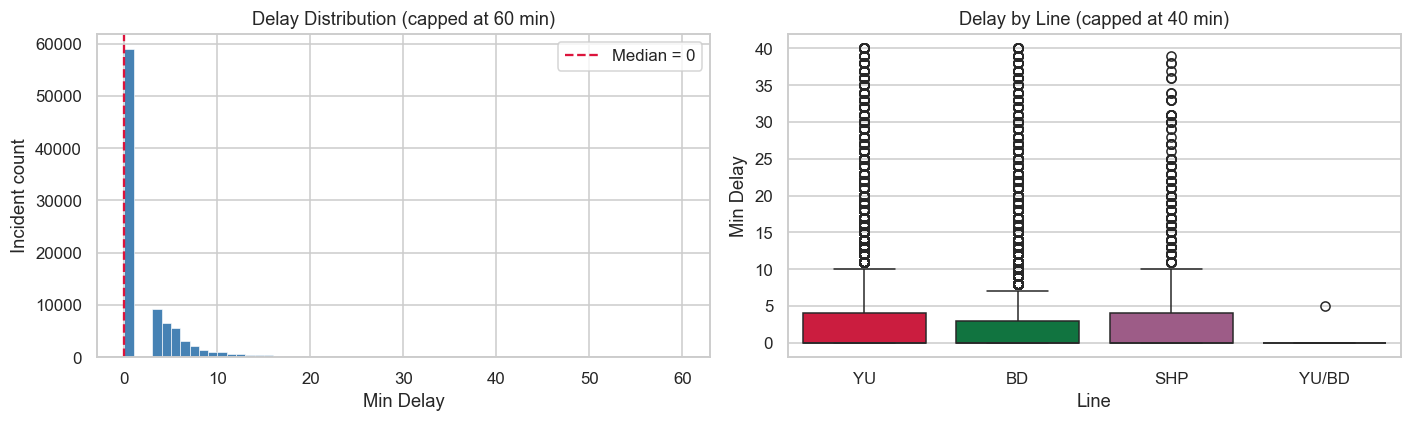

Rows with zero delay : 62.3%  (incidents logged but service not impacted)
Rows delayed >= 5 min: 21.1%
Max single delay     : 900 min (15.0 hours)


In [17]:
# plottig delay dstribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# histogram, capped at 60 min so the shape is visible
df_plot = df[df["Min Delay"] <= 60]
axes[0].hist(df_plot["Min Delay"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Min Delay")
axes[0].set_ylabel("Incident count")
axes[0].set_title("Delay Distribution (capped at 60 min)")
axes[0].axvline(df["Min Delay"].median(), color="crimson", linestyle="--", label=f"Median = {df['Min Delay'].median():.0f}")
axes[0].legend()

# box plot by line
sns.boxplot(data=df[df["Min Delay"] <= 40], x="Line", y="Min Delay",
            order=["YU","BD","SHP","YU/BD"], ax=axes[1],
            palette={"YU":"#E8002D","BD":"#00853F","SHP":"#A8518A","YU/BD":"#F5A623"})
axes[1].set_title("Delay by Line (capped at 40 min)")
axes[1].set_xlabel("Line")
axes[1].set_ylabel("Min Delay")

plt.tight_layout()
plt.show()

zero_pct = (df["Min Delay"] == 0).mean()
print(f"Rows with zero delay : {zero_pct:.1%}  (incidents logged but service not impacted)")
print(f"Rows delayed >= 5 min: {(df['Min Delay'] >= 5).mean():.1%}")
print(f"Max single delay     : {df['Min Delay'].max()} min ({df['Min Delay'].max()/60:.1f} hours)")

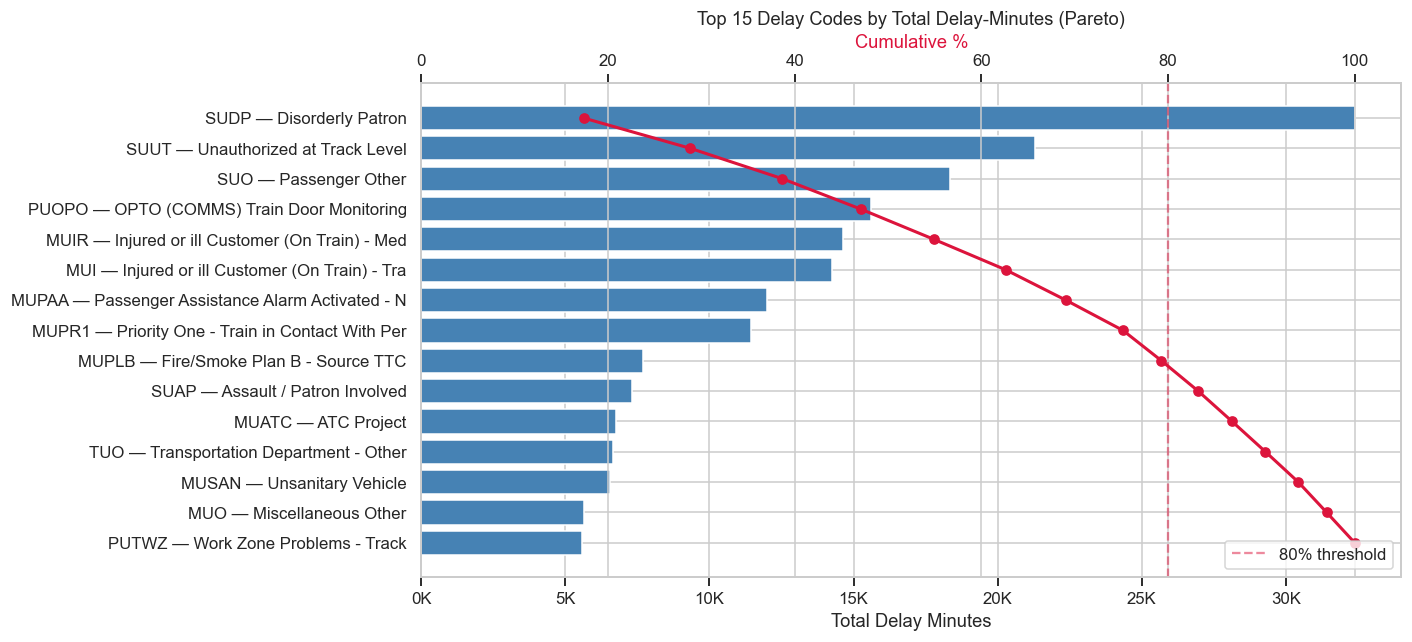

Top 5 codes account for 35.8% of all delay-minutes


In [19]:
# pareto chart for top 15 delay codes
top_codes = (
    df[df["Min Delay"] > 0]
    .groupby(["Code", "Description"])["Min Delay"]
    .sum()
    .reset_index()
    .sort_values("Min Delay", ascending=False)
    .head(15)
)
top_codes["Cumulative %"] = top_codes["Min Delay"].cumsum() / top_codes["Min Delay"].sum() * 100
top_codes["Label"] = top_codes["Code"] + " — " + top_codes["Description"].str[:40]

fig, ax1 = plt.subplots(figsize=(13, 6))
bars = ax1.barh(top_codes["Label"][::-1], top_codes["Min Delay"][::-1], color="steelblue")
ax1.set_xlabel("Total Delay Minutes")
ax1.set_title("Top 15 Delay Codes by Total Delay-Minutes (Pareto)")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

ax2 = ax1.twiny()
ax2.plot(top_codes["Cumulative %"][::-1], range(len(top_codes)), "o-", color="crimson", linewidth=2)
ax2.set_xlabel("Cumulative %", color="crimson")
ax2.set_xlim(0, 105)
ax2.axvline(80, color="crimson", linestyle="--", alpha=0.5, label="80% threshold")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

top5_pct = top_codes["Min Delay"].head(5).sum() / df["Min Delay"].sum() * 100
print(f"Top 5 codes account for {top5_pct:.1f}% of all delay-minutes")

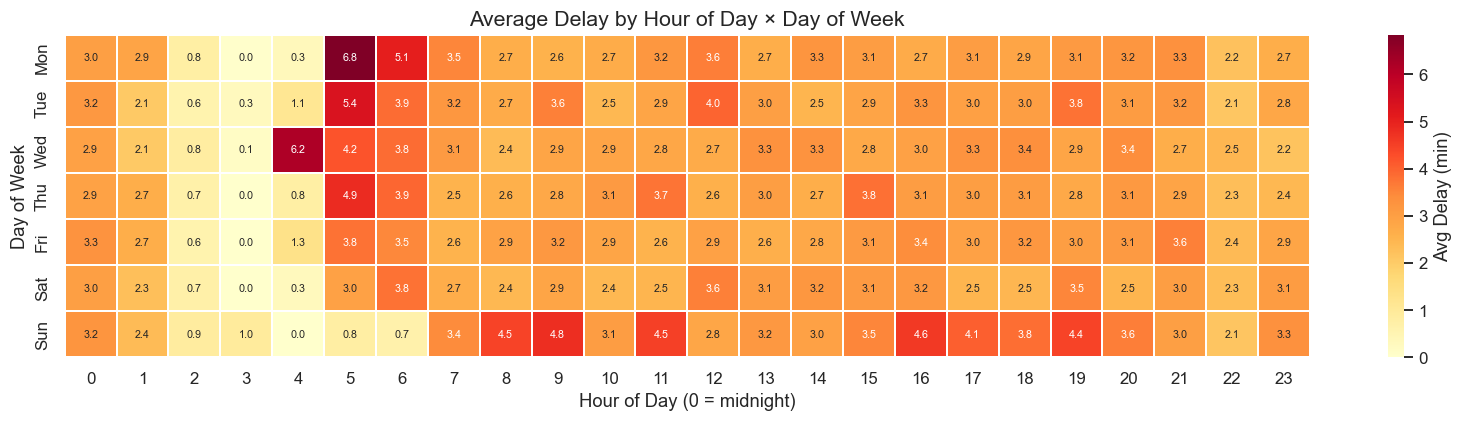

In [20]:
# hour x weekday heaatmap for Min Delay
pivot = (
    df.groupby(["Weekday", "Hour"])["Min Delay"]
    .mean()
    .reset_index()
    .pivot(index="Weekday", columns="Hour", values="Min Delay")
)
# Label weekdays 0-6 as names
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot.index = day_labels

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
    cbar_kws={"label": "Avg Delay (min)"},
    annot=True, fmt=".1f", annot_kws={"size": 7}
)
ax.set_title("Average Delay by Hour of Day × Day of Week", fontsize=14)
ax.set_xlabel("Hour of Day (0 = midnight)")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.show()

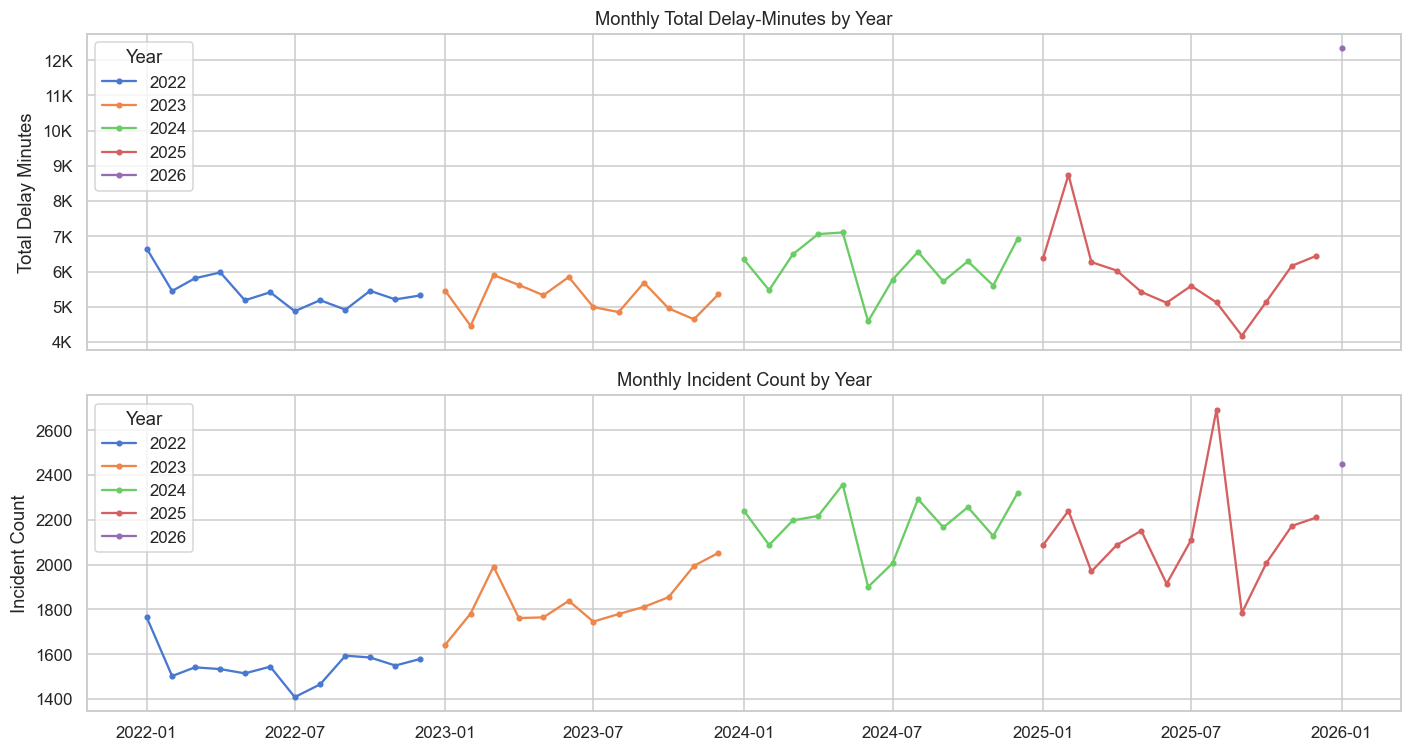

In [21]:
# monthly trend by year
monthly = (
    df.groupby(["Year", "Month"])
    .agg(Total_Delay=("Min Delay", "sum"), Incidents=("Min Delay", "count"))
    .reset_index()
)
monthly["YearMonth"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str).str.zfill(2) + "-01"
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for yr, grp in monthly.groupby("Year"):
    axes[0].plot(grp["YearMonth"], grp["Total_Delay"], marker="o", markersize=3, label=str(yr))
axes[0].set_ylabel("Total Delay Minutes")
axes[0].set_title("Monthly Total Delay-Minutes by Year")
axes[0].legend(title="Year")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

for yr, grp in monthly.groupby("Year"):
    axes[1].plot(grp["YearMonth"], grp["Incidents"], marker="o", markersize=3, label=str(yr))
axes[1].set_ylabel("Incident Count")
axes[1].set_title("Monthly Incident Count by Year")
axes[1].legend(title="Year")

plt.tight_layout()
plt.show()

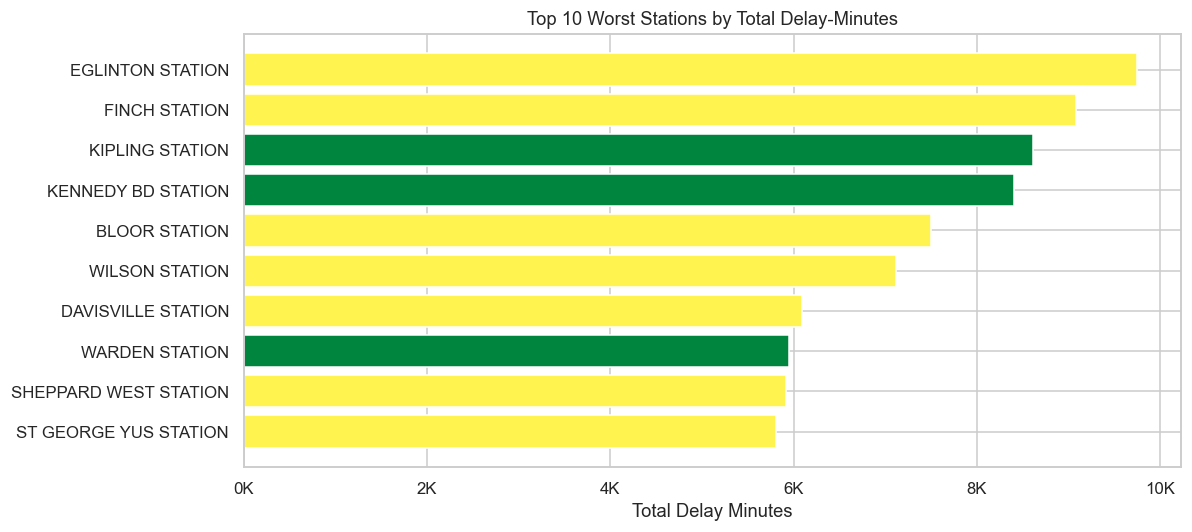

              Station Line  Total_Delay_Min  Incident_Count  Avg_Delay
     EGLINTON STATION   YU             9744            1368        7.1
        FINCH STATION   YU             9085            1519        6.0
      KIPLING STATION   BD             8613            1293        6.7
   KENNEDY BD STATION   BD             8401            1296        6.5
        BLOOR STATION   YU             7497            1126        6.7
       WILSON STATION   YU             7122            1062        6.7
   DAVISVILLE STATION   YU             6088             763        8.0
       WARDEN STATION   BD             5946             637        9.3
SHEPPARD WEST STATION   YU             5920             573       10.3
ST GEORGE YUS STATION   YU             5813             835        7.0


In [23]:
# worst station by total delay minutes
station_stats = (
    df[df["Min Delay"] > 0]
    .groupby(["Station", "Line"])
    .agg(
        Total_Delay_Min=("Min Delay", "sum"),
        Incident_Count=("Min Delay", "count"),
        Avg_Delay=("Min Delay", "mean"),
    )
    .reset_index()
    .sort_values("Total_Delay_Min", ascending=False)
    .head(10)
)
station_stats["Avg_Delay"] = station_stats["Avg_Delay"].round(1)

fig, ax = plt.subplots(figsize=(11, 5))
colors = {"YU": "#FFF350", "BD": "#00853F", "SHP": "#A8518A", "YU/BD": "#F5A623"}
bar_colors = [colors.get(l, "gray") for l in station_stats["Line"]]
ax.barh(station_stats["Station"][::-1], station_stats["Total_Delay_Min"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Total Delay Minutes")
ax.set_title("Top 10 Worst Stations by Total Delay-Minutes")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.show()

print(station_stats[["Station","Line","Total_Delay_Min","Incident_Count","Avg_Delay"]].to_string(index=False))

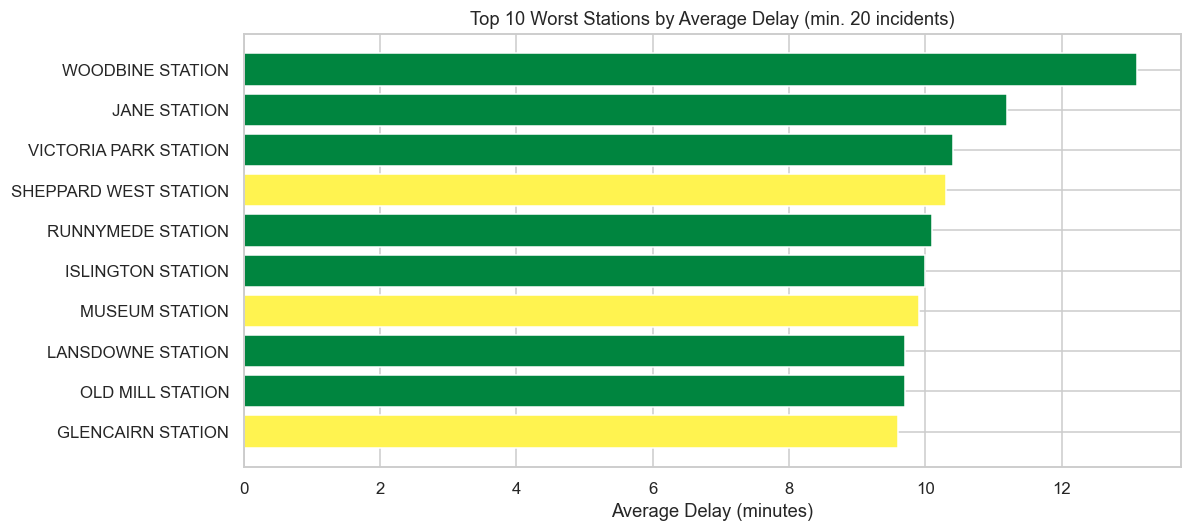

              Station Line  Avg_Delay  Incident_Count  Total_Delay_Min
     WOODBINE STATION   BD       13.1             248             3249
         JANE STATION   BD       11.2             242             2720
VICTORIA PARK STATION   BD       10.4             520             5428
SHEPPARD WEST STATION   YU       10.3             573             5920
    RUNNYMEDE STATION   BD       10.1             156             1572
    ISLINGTON STATION   BD       10.0             392             3915
       MUSEUM STATION   YU        9.9             295             2931
    LANSDOWNE STATION   BD        9.7             221             2142
     OLD MILL STATION   BD        9.7             238             2316
    GLENCAIRN STATION   YU        9.6             251             2406


In [26]:
# top 10 worst stations by average delay (minimum 20 incidents to qualify)
MIN_INCIDENTS = 20

station_avg = (
    df[df["Min Delay"] > 0]
    .groupby(["Station", "Line"])
    .agg(
        Total_Delay_Min=("Min Delay", "sum"),
        Incident_Count=("Min Delay", "count"),
        Avg_Delay=("Min Delay", "mean"),
    )
    .reset_index()
)
station_avg["Avg_Delay"] = station_avg["Avg_Delay"].round(1)

# filter out stations with too few incidents before ranking
station_avg_filtered = (
    station_avg[station_avg["Incident_Count"] >= MIN_INCIDENTS]
    .sort_values("Avg_Delay", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = {"YU": "#FFF350", "BD": "#00853F", "SHP": "#A8518A", "YU/BD": "#F5A623"}
bar_colors = [colors.get(l, "gray") for l in station_avg_filtered["Line"]]
ax.barh(station_avg_filtered["Station"][::-1], station_avg_filtered["Avg_Delay"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Average Delay (minutes)")
ax.set_title(f"Top 10 Worst Stations by Average Delay (min. {MIN_INCIDENTS} incidents)")
plt.tight_layout()
plt.show()

print(station_avg_filtered[["Station","Line","Avg_Delay","Incident_Count","Total_Delay_Min"]].to_string(index=False))


In [27]:
# merge weather data
WEATHER_CACHE   = DATA_DIR / "weather_toronto.csv"
if WEATHER_CACHE.exists():
    df_weather = pd.read_csv(WEATHER_CACHE, parse_dates=["time"])
    print(f"Loaded cached weather data: {len(df_weather):,} rows")
else:
    print("Fetching weather from Open-Meteo API...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude" : 43.6532,
        "longitude": -79.3832,
        "start_date": "2022-01-01",
        "end_date"  : END_DATE,
        "hourly"    : "temperature_2m,precipitation,rain,snowfall,snow_depth,wind_speed_10m,weather_code",
        "timezone"  : "America/Toronto",
    }
    resp = requests.get(url, params=params, timeout=90)
    resp.raise_for_status()
    df_weather = pd.DataFrame(resp.json()["hourly"])
    df_weather["time"] = pd.to_datetime(df_weather["time"])
    df_weather.to_csv(WEATHER_CACHE, index=False)
    print(f"Fetched and cached: {len(df_weather):,} rows ({WEATHER_CACHE})")

print(f"Weather range: {df_weather['time'].min().date()} to {df_weather['time'].max().date()}")
df_weather.head(3)

Loaded cached weather data: 35,808 rows
Weather range: 2022-01-01 to 2026-01-31


,time,temperature_2m,precipitation,rain,snowfall,snow_depth,wind_speed_10m,weather_code
0,2022-01-01 00:00:00,3.8,0.0,0.0,0.0,0.02,9.1,3
1,2022-01-01 01:00:00,3.3,0.0,0.0,0.0,0.02,5.1,3
2,2022-01-01 02:00:00,3.5,0.0,0.0,0.0,0.02,11.5,3


In [28]:
# merge weather onto delay data, round delay timestamp down to the hour
df["hour_floor"] = df["Datetime"].dt.floor("h")
df = df.merge(
    df_weather.rename(columns={"time": "hour_floor"}),
    on="hour_floor",
    how="left",
)
weather_coverage = df["temperature_2m"].notna().mean()
df = df.drop(columns=["hour_floor"])

In [32]:
df.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,...,Peak_Hour,Weekend,Season,temperature_2m,precipitation,rain,snowfall,snow_depth,wind_speed_10m,weather_code
0,2022-01-01 00:00:00,02:23,Saturday,SPADINA BD STATION,MUIS,0,0,NaN,BD,0,...,0,1,Winter,3.5,0.0,0.0,0.0,0.02,11.5,3
1,2022-01-01 00:00:00,02:28,Saturday,VAUGHAN MC STATION,MUIS,0,0,NaN,YU,0,...,0,1,Winter,3.5,0.0,0.0,0.0,0.02,11.5,3
2,2022-01-01 00:00:00,02:34,Saturday,EGLINTON STATION,MUATC,0,0,S,YU,5981,...,0,1,Winter,3.5,0.0,0.0,0.0,0.02,11.5,3
3,2022-01-01 00:00:00,05:40,Saturday,QUEEN STATION,MUNOA,0,0,NaN,YU,0,...,0,1,Winter,3.7,0.1,0.1,0.0,0.02,8.5,51
4,2022-01-01 00:00:00,06:56,Saturday,DAVISVILLE STATION,MUNOA,0,0,NaN,YU,0,...,0,1,Winter,3.5,0.1,0.1,0.0,0.02,6.5,51


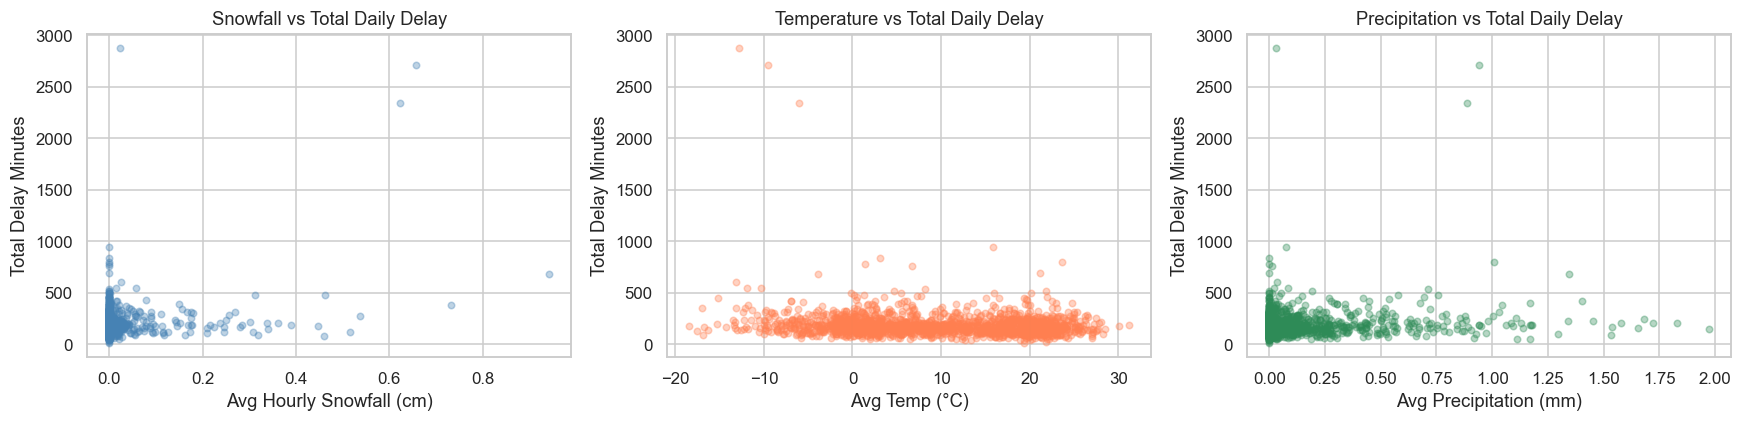

Snow days   :    6 days — avg total delay 1086 min
Normal days : 1486 days — avg total delay 188 min
Delta       : +898 min on snow days


In [29]:
# weather impact visualization
# aggregate to daily level for cleaner scatter plots
df_daily = (
    df.groupby(df["Datetime"].dt.date)
    .agg(
        Total_Delay_Min=("Min Delay", "sum"),
        Incident_Count=("Min Delay", "count"),
        Avg_Snowfall=("snowfall", "mean"),
        Avg_Temp=("temperature_2m", "mean"),
        Avg_Precip=("precipitation", "mean"),
    )
    .reset_index()
    .rename(columns={"Datetime": "Date"})
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df_daily["Avg_Snowfall"], df_daily["Total_Delay_Min"],
                alpha=0.35, color="steelblue", s=18)
axes[0].set_xlabel("Avg Hourly Snowfall (cm)"); axes[0].set_ylabel("Total Delay Minutes")
axes[0].set_title("Snowfall vs Total Daily Delay")

axes[1].scatter(df_daily["Avg_Temp"], df_daily["Total_Delay_Min"],
                alpha=0.35, color="coral", s=18)
axes[1].set_xlabel("Avg Temp (°C)"); axes[1].set_ylabel("Total Delay Minutes")
axes[1].set_title("Temperature vs Total Daily Delay")

axes[2].scatter(df_daily["Avg_Precip"], df_daily["Total_Delay_Min"],
                alpha=0.35, color="seagreen", s=18)
axes[2].set_xlabel("Avg Precipitation (mm)"); axes[2].set_ylabel("Total Delay Minutes")
axes[2].set_title("Precipitation vs Total Daily Delay")

plt.tight_layout()
plt.show()

# snow day vs normal day comparison
snow_days   = df_daily[df_daily["Avg_Snowfall"] > 0.5]
normal_days = df_daily[df_daily["Avg_Snowfall"] <= 0.5]
print(f"Snow days   : {len(snow_days):>4} days — avg total delay {snow_days['Total_Delay_Min'].mean():.0f} min")
print(f"Normal days : {len(normal_days):>4} days — avg total delay {normal_days['Total_Delay_Min'].mean():.0f} min")
print(f"Delta       : +{snow_days['Total_Delay_Min'].mean() - normal_days['Total_Delay_Min'].mean():.0f} min on snow days")